S.ASWIN 24BAD014
Best k: 5


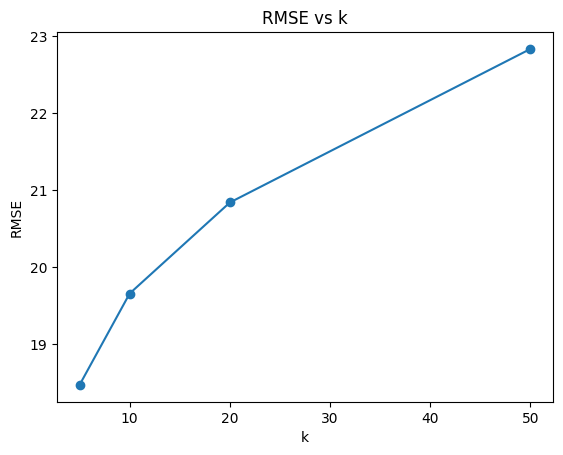

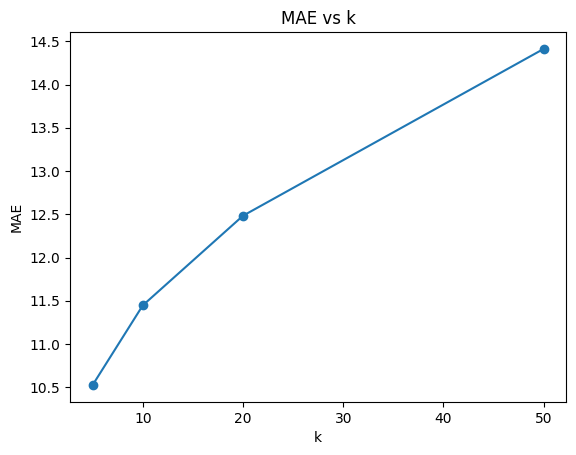

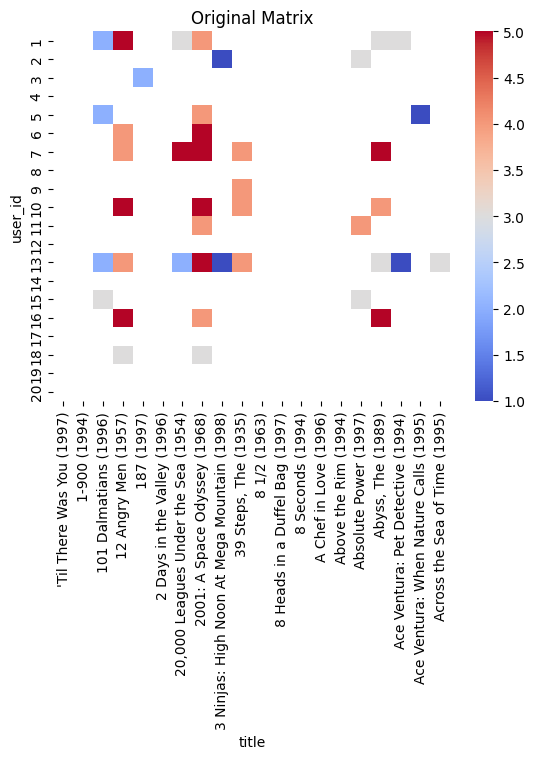

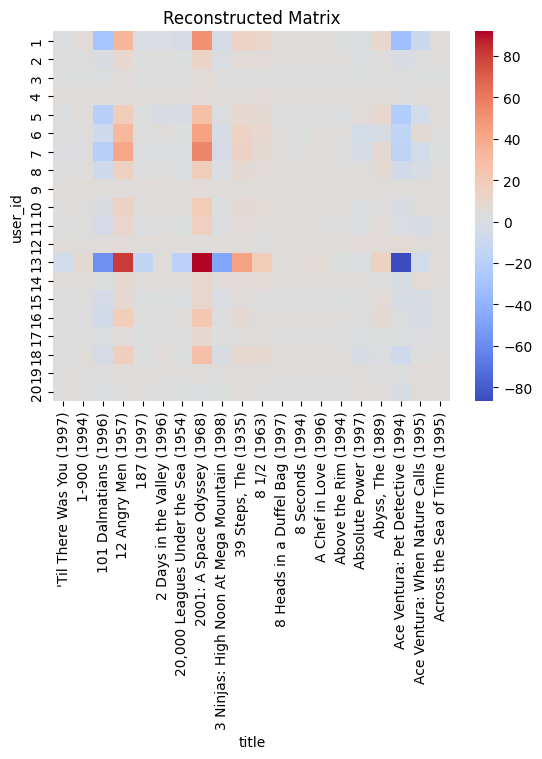


Top Recommendations for User 1:
title
Casablanca (1942)                                                              69.867286
Schindler's List (1993)                                                        62.500815
Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1963)    59.532661
One Flew Over the Cuckoo's Nest (1975)                                         53.246622
Rear Window (1954)                                                             51.449070
Name: 1, dtype: float64


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error, mean_absolute_error

ratings_url = "https://files.grouplens.org/datasets/movielens/ml-100k/u.data"
movies_url = "https://files.grouplens.org/datasets/movielens/ml-100k/u.item"

ratings = pd.read_csv(ratings_url, sep="\t", names=["user_id", "movie_id", "rating", "timestamp"])
movies = pd.read_csv(movies_url, sep="|", encoding="latin-1", header=None, usecols=[0, 1], names=["movie_id", "title"])

df = pd.merge(ratings, movies, on="movie_id")
df.drop("timestamp", axis=1, inplace=True)

print("S.ASWIN 24BAD014")
user_item_matrix = df.pivot_table(index="user_id", columns="title", values="rating", aggfunc="mean")

original_matrix = user_item_matrix.copy()

user_means = user_item_matrix.mean(axis=1)
user_item_centered = user_item_matrix.sub(user_means, axis=0)
user_item_centered = user_item_centered.fillna(0)

k_values = [5, 10, 20, 50]
rmse_list = []
mae_list = []

best_k = None
best_rmse = float('inf')
reconstructed_final = None

for k in k_values:
    svd = TruncatedSVD(n_components=k, random_state=42)
    U = svd.fit_transform(user_item_centered)
    Sigma = svd.singular_values_
    VT = svd.components_

    reconstructed = np.dot(U, np.dot(np.diag(Sigma), VT))
    reconstructed = reconstructed + user_means.values.reshape(-1, 1)

    reconstructed_df = pd.DataFrame(reconstructed, index=user_item_matrix.index, columns=user_item_matrix.columns)

    actual = original_matrix.values.flatten()
    predicted = reconstructed_df.values.flatten()

    mask = ~np.isnan(actual)
    actual = actual[mask]
    predicted = predicted[mask]

    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)

    rmse_list.append(rmse)
    mae_list.append(mae)

    if rmse < best_rmse:
        best_rmse = rmse
        best_k = k
        reconstructed_final = reconstructed_df

print("Best k:", best_k)

plt.figure()
plt.plot(k_values, rmse_list, marker='o')
plt.xlabel("k")
plt.ylabel("RMSE")
plt.title("RMSE vs k")
plt.show()

plt.figure()
plt.plot(k_values, mae_list, marker='o')
plt.xlabel("k")
plt.ylabel("MAE")
plt.title("MAE vs k")
plt.show()

plt.figure()
sns.heatmap(original_matrix.iloc[:20, :20], cmap="coolwarm")
plt.title("Original Matrix")
plt.show()

plt.figure()
sns.heatmap(reconstructed_final.iloc[:20, :20], cmap="coolwarm")
plt.title("Reconstructed Matrix")
plt.show()

def recommend_movies(user_id, reconstructed_df, original_matrix, n=5):
    user_row = reconstructed_df.loc[user_id]
    seen_movies = original_matrix.loc[user_id].dropna().index
    recommendations = user_row.drop(seen_movies)
    return recommendations.sort_values(ascending=False).head(n)

print("\nTop Recommendations for User 1:")
print(recommend_movies(1, reconstructed_final, original_matrix, 5))

/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


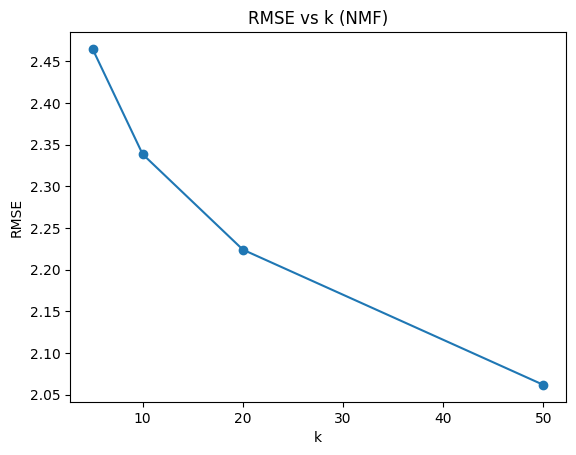

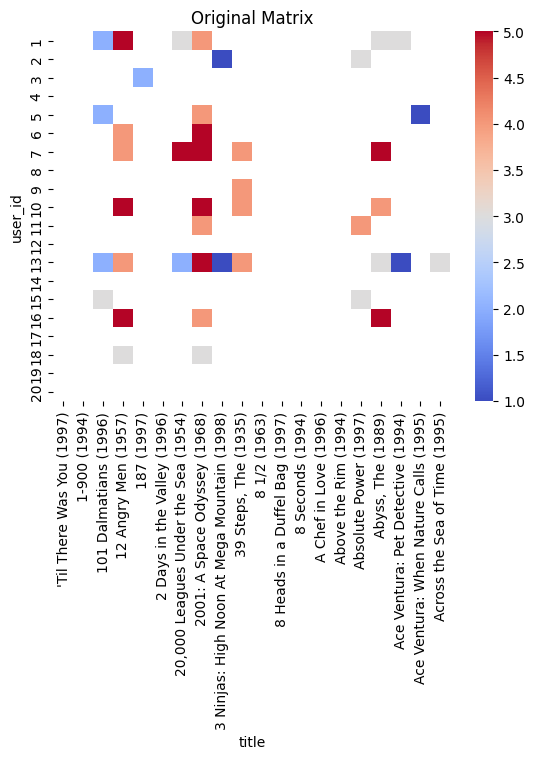

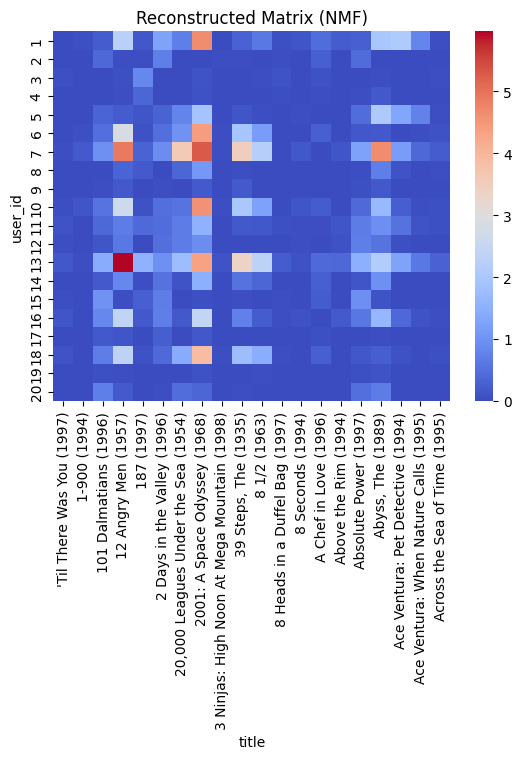

Top Recommendations for User 1:
title
Secrets & Lies (1996)                4.677830
Stand by Me (1986)                   3.966836
E.T. the Extra-Terrestrial (1982)    3.904389
Close Shave, A (1995)                3.682917
Trainspotting (1996)                 3.607581
Name: 1, dtype: float64
Precision@5: 0.9465535524920465
Recall@5: 0.08915600077793454


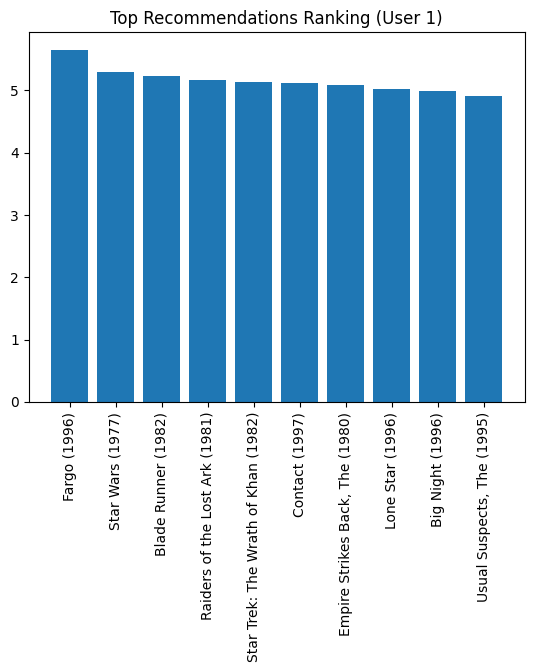

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error

ratings_url = "https://files.grouplens.org/datasets/movielens/ml-100k/u.data"
movies_url = "https://files.grouplens.org/datasets/movielens/ml-100k/u.item"

ratings = pd.read_csv(ratings_url, sep="\t", names=["user_id", "movie_id", "rating", "timestamp"])
movies = pd.read_csv(movies_url, sep="|", encoding="latin-1", header=None, usecols=[0, 1], names=["movie_id", "title"])

df = pd.merge(ratings, movies, on="movie_id")
df.drop("timestamp", axis=1, inplace=True)

user_item_matrix = df.pivot_table(index="user_id", columns="title", values="rating", aggfunc="mean")
original_matrix = user_item_matrix.copy()

user_item_filled = user_item_matrix.fillna(0)

k_values = [5, 10, 20, 50]
rmse_list = []
reconstructed_final = None
best_rmse = float("inf")

for k in k_values:
    nmf = NMF(n_components=k, init='random', random_state=42, max_iter=200)
    W = nmf.fit_transform(user_item_filled)
    H = nmf.components_

    reconstructed = np.dot(W, H)
    reconstructed_df = pd.DataFrame(reconstructed, index=user_item_matrix.index, columns=user_item_matrix.columns)

    actual = original_matrix.values.flatten()
    predicted = reconstructed_df.values.flatten()

    mask = ~np.isnan(actual)
    actual = actual[mask]
    predicted = predicted[mask]

    rmse = np.sqrt(mean_squared_error(actual, predicted))
    rmse_list.append(rmse)

    if rmse < best_rmse:
        best_rmse = rmse
        reconstructed_final = reconstructed_df

plt.figure()
plt.plot(k_values, rmse_list, marker='o')
plt.xlabel("k")
plt.ylabel("RMSE")
plt.title("RMSE vs k (NMF)")
plt.show()

plt.figure()
sns.heatmap(user_item_matrix.iloc[:20, :20], cmap="coolwarm")
plt.title("Original Matrix")
plt.show()

plt.figure()
sns.heatmap(reconstructed_final.iloc[:20, :20], cmap="coolwarm")
plt.title("Reconstructed Matrix (NMF)")
plt.show()

def recommend_movies(user_id, reconstructed_df, original_matrix, n=5):
    user_row = reconstructed_df.loc[user_id]
    seen_movies = original_matrix.loc[user_id].dropna().index
    recommendations = user_row.drop(seen_movies)
    return recommendations.sort_values(ascending=False).head(n)

print("Top Recommendations for User 1:")
print(recommend_movies(1, reconstructed_final, original_matrix, 5))

def precision_recall_at_k(original, predicted, k=5):
    precision_list = []
    recall_list = []
    for user in original.index:
        actual_items = original.loc[user].dropna().index
        predicted_items = predicted.loc[user].sort_values(ascending=False).head(k).index

        tp = len(set(actual_items) & set(predicted_items))
        precision = tp / k
        recall = tp / len(actual_items) if len(actual_items) > 0 else 0

        precision_list.append(precision)
        recall_list.append(recall)

    return np.mean(precision_list), np.mean(recall_list)

precision, recall = precision_recall_at_k(original_matrix, reconstructed_final, k=5)

print("Precision@5:", precision)
print("Recall@5:", recall)

top_movies = reconstructed_final.iloc[0].sort_values(ascending=False).head(10)

plt.figure()
plt.bar(range(10), top_movies.values)
plt.xticks(range(10), top_movies.index, rotation=90)
plt.title("Top Recommendations Ranking (User 1)")
plt.show()